# Where US Tech Firms Can Lease Smart: Availability, Affordability, and Flexibility in the Post\-Covid World

##                                                El Camino College ASA DataFest 2025

> Project By: The Hammers \(Joseph Jung, Maxime Chung, Edwin Kofler, Shubham Waldiya\)

In [1]:

from dateutil.parser import parse as _deepnote_parse
Demo_Date = _deepnote_parse('2025-04-13T00:00:00.000Z').date()


In [2]:
pip install plotly


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.io as pio

In [4]:
lease = pd.read_csv("Leases.csv") 
price_availability_df = pd.read_csv("Price and Availability Data.csv")
occupancy_df = pd.read_csv("Major Market Occupancy Data-revised-20250412-051645.csv")

# Problem

COVID-19 has changed the way people work. Many companies have transitioned to remote-only or hybrid work. Furthermore, with a worsening climate crisis, businesses are expected to handle the cost of additional disruptions to their business.

How can business minimize the cost and cope with the effects of more frequent natural disasters?

Our team approached this in two ways:

**1. Identify U.S. office markets in the tech industry that have shown to be most suited to hybrid/remote work**

- The tech industry leaded in remote and hybrid work 
- Rank markets with a "flexible office leasing" value


**2. Cater recommendations by business size**

- Larger businesses will require higher office square footage

# Map of Top Tech Post\-COVID Flexible Office Markets

## Why "Tech Industry"?

Tech Companies are the most innovational ones that have dynamic space needs and the highest remote adoption. 
It went remote the earliest during COVID-19. 

## What does " flexible" mean in this context?

"Flexible" means that the lease agreement isn’t completely rigid\. Instead of being locked into a set, unchanging amount of space over a long period, a flexible lease can include options that allow a company to adjust how much space it uses as its needs change\. This might mean:

Option to Downsize → Ability to sublease unused space & Flexible reduction in space use

Option to Expand → Scalable space for growth &  Capacity to add headcount onsite

Shorter Lease Terms → Short contracts or flexible renewals let companies reassess space needs regularly\.

In short, "flexible" means that the company has room to adapt its office space usage over time—helping it manage costs and space effectively, even in a hybrid work setup

### What determines HIGH Flexibility Score?

In [1]:
import IPython.display as display

# the table content
data = {
    "Metric": [
        "sublet_availability_prop",
        "availability_prop",
        "avg_occupancy_prop",
        "overall_rent"
    ],
    "What It Tells Us": [
        "% of space availble for sublease",
        "Overall space available in the market",
        "% of the building currently in use",
        "Avg rent ($/sqft)"
    ],
    "Impact on Flexibility Score": [
        "⬆️ Higher: More flexible options",
        "⬆️ Higher: Easier to lease space",
        "⬆️ Higher: Signals demand and active usage",
        "⬇️ Lower: More cost-effective"
    ]
}

df = pd.DataFrame(data)
display.display(df.style.hide(axis="index").set_properties(**{
        'text-align': 'left',
        'font-size': '13.5px'
    }))

NameError: name 'pd' is not defined

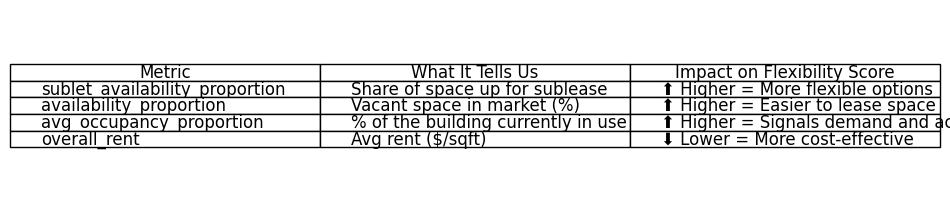

In [6]:
import matplotlib.pyplot as plt
import matplotlib.table as tbl

# Table data
data = {
    "Metric": [
        "sublet_availability_proportion",
        "availability_proportion",
        "avg_occupancy_proportion",
        "overall_rent"
    ],
    "What It Tells Us": [
        "Share of space up for sublease",
        "Vacant space in market (%)",
        "% of the building currently in use",
        "Avg rent ($/sqft)"
    ],
    "Impact on Flexibility Score": [
        "⬆️ Higher = More flexible options",
        "⬆️ Higher = Easier to lease space",
        "⬆️ Higher = Signals demand and active usage",
        "⬇️ Lower = More cost-effective"
    ]
}

df = pd.DataFrame(data)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2.5))  # make it a bit wider
ax.axis('off')

# Create table
table = tbl.table(
    ax,
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='left',
    loc='center'
)

# Make fonts bigger
table.auto_set_font_size(False)
table.set_fontsize(12)  # 🔥 adjust this number to make text larger

# Save table
plt.savefig("flexibility_metrics_table.png", bbox_inches='tight', dpi=200)
plt.show()


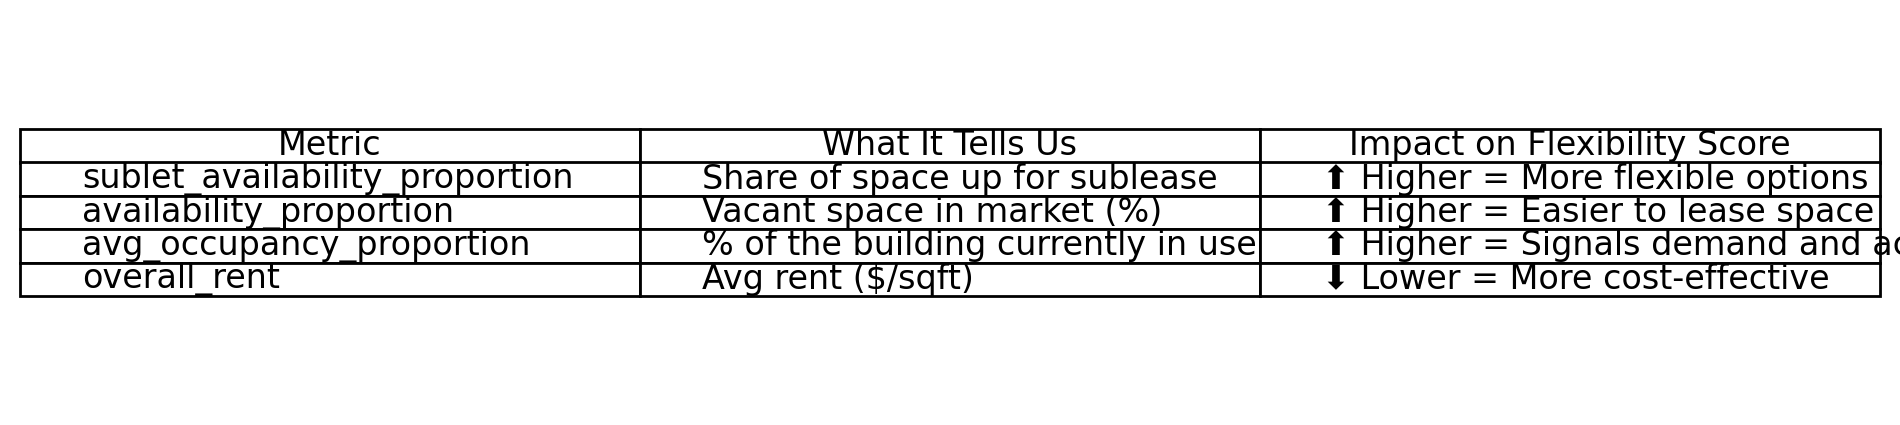

In [7]:
from IPython.display import Image
Image("flexibility_metrics_table.png")

## ⚡ Why It Matters

- Hybrid work is driving new space needs
- Tech firms want flexibility to expand or contract
- These cities offer the most leasing agility

In [8]:
pio.renderers.default = 'notebook_connected'

# Aggregate by market
sublet_grouped = lease.groupby("market", as_index=False)["sublet_availability_proportion"].mean()
occupancy_grouped = occupancy_df.groupby("market", as_index=False)["avg_occupancy_proportion"].mean()
price_grouped = price_availability_df.groupby("market", as_index=False)[
    ["availability_proportion", "overall_rent"]
].mean()

# Merge data
merged_df = price_grouped.merge(sublet_grouped, on="market", how="left")
merged_df = merged_df.merge(occupancy_grouped, on="market", how="left")
print("Missing values:\n", merged_df.isna().sum())
print("Rows before cleaning:", merged_df.shape[0])

# Drop rows with missing critical data
merged_df.dropna(subset=[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
], inplace=True)
print("Rows after cleaning:", merged_df.shape[0])

# Scale and score
scaler = MinMaxScaler()
scaled = scaler.fit_transform(merged_df[[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
]])
scaled[:, 2] = 1 - scaled[:, 2]  # Invert rent (lower rent is better)

weights = np.array([0.25, 0.25, 0.25, 0.25])
merged_df["flexible_office_score"] = np.dot(scaled, weights)

# Come up with the score dataset
score_df = merged_df.sort_values(by="flexible_office_score", ascending=False)


Missing values:
 market                             0
availability_proportion            0
overall_rent                       0
sublet_availability_proportion     9
avg_occupancy_proportion          24
dtype: int64
Rows before cleaning: 30
Rows after cleaning: 6


In [9]:
%pip install geopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 7.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
city = {
    "Houston": (29.7604, -95.3698),
    "Austin": (30.2672, -97.7431),
    "Los Angeles": (34.0522, -118.2437),
    "San Francisco": (37.7749, -122.4194),
    "Philadelphia": (39.9526, -75.1652),
    "Manhattan": (40.7128, -74.0060),
    "Seattle": (47.6062, -122.3321),
    "Boston": (42.3601, -71.0589),
    "Chicago": (41.8781, -87.6298),
    "Denver": (39.7392, -104.9903),
    "Atlanta": (33.7490, -84.3880),
    "Dallas": (32.7767, -96.7970),
    "San Diego": (32.7157, -117.1611),
    "San Jose": (37.3382, -121.8863),
    "Phoenix": (33.4484, -112.0740),
    "Miami": (25.7617, -80.1918),
    "Portland": (45.5051, -122.6750),
    "Minneapolis": (44.9778, -93.2650),
    "Raleigh": (35.7796, -78.6382),
    "Salt Lake City": (40.7608, -111.8910)
}
# from geopy import geocoders
# from geopy.geocoders import Nominatim

# gn = geocoders.GeoNames(username='hyperupcall')
# app = Nominatim(user_agent="tutorial")
# location = app.geocode("Nairobi, Kenya").raw
# print(location)
# def f1(x):
#     print(x)
#     return app.geocode(x).raw.lat

# def f2(x):
#     print(x)
#     return app.geocode(x).raw.lon

score_df1 = score_df.copy()
# score_df1 = merged_df.copy()
# merged_df

score_df1["lat"] = score_df1['market'].map(lambda x: city.get(x, (None, None))[0])
score_df1["lon"]= score_df1["market"].map(lambda x: city.get(x, (None, None))[1])
fig = px.scatter_geo(
    score_df1,
    lat="lat",
    lon="lon",
    # locations='market',
    size="flexible_office_score",
    color="flexible_office_score",
    hover_name="market",
    # projection="albers usa",
    # fitbounds="locations",  # auto-zoom
    title="Top U.S. Office Markets for Flexible Leasing",
    # size_max=25,
    # scope='usa'
    # color_continuous_scale="Viridis"
)
fig.update_layout(geo=dict(scope="usa"))
# # fig.update_traces(marker=dict(size=10, color='red'))

fig.show()

# # Save the map to an HTML file? Can't display here or render 
# # fig.write_html("flexible_office_map.html")


In [11]:
lease.columns = lease.columns.str.strip().str.lower()
price_availability_df.columns = price_availability_df.columns.str.strip().str.lower()
occupancy_df.columns = occupancy_df.columns.str.strip().str.lower()

# Filter for tech
tech_leases = lease[lease["internal_industry"].str.contains("technology|it|information", case=False, na=False)]

# Aggregate by market
sublet_grouped_tech = tech_leases.groupby("market", as_index=False)["sublet_availability_proportion"].mean()
price_grouped = price_availability_df.groupby("market", as_index=False)[["availability_proportion", "overall_rent"]].mean()
occupancy_grouped = occupancy_df.groupby("market", as_index=False)["avg_occupancy_proportion"].mean()

# Merge all data
merged_df = price_grouped.merge(sublet_grouped_tech, on="market", how="left")
merged_df = merged_df.merge(occupancy_grouped, on="market", how="left")

# Drop missing values
merged_df.dropna(subset=[
    "availability_proportion", "sublet_availability_proportion", 
    "overall_rent", "avg_occupancy_proportion"
], inplace=True)

# Step 5: Normalize and compute score
scaler = MinMaxScaler()
scaled = scaler.fit_transform(merged_df[[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
]])
scaled[:, 2] = 1 - scaled[:, 2]  # invert rent

weights = np.array([0.25, 0.25, 0.25, 0.25])
merged_df["tech_flexible_office_score"] = np.dot(scaled, weights)


score_df_tech = merged_df.sort_values(by="tech_flexible_office_score", ascending=False)


## Map of Leading Tech Office Markets by Space Flexibility

### These cities offer the most leasing agility based on the 4 available metrics we chose\!

In [12]:


city_coords = {
    "Houston": (29.7604, -95.3698),
    "Austin": (30.2672, -97.7431),
    "Los Angeles": (34.0522, -118.2437),
    "San Francisco": (37.7749, -122.4194),
    "Philadelphia": (39.9526, -75.1652),
    "Manhattan": (40.7128, -74.0060),
    "Seattle": (47.6062, -122.3321),
    "Boston": (42.3601, -71.0589),
    "Chicago": (41.8781, -87.6298),
    "Denver": (39.7392, -104.9903),
    "Atlanta": (33.7490, -84.3880),
    "Dallas": (32.7767, -96.7970),
    "San Diego": (32.7157, -117.1611),
    "San Jose": (37.3382, -121.8863),
    "Phoenix": (33.4484, -112.0740),
    "Miami": (25.7617, -80.1918),
    "Portland": (45.5051, -122.6750),
    "Minneapolis": (44.9778, -93.2650),
    "Raleigh": (35.7796, -78.6382),
    "Salt Lake City": (40.7608, -111.8910)

}

score_df_tech = merged_df.copy()
score_df_tech["lat"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[0])
score_df_tech["lon"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[1])
score_df_tech.dropna(subset=["lat", "lon"], inplace=True)


fig = px.scatter_geo(
    score_df_tech,
    lat="lat",
    lon="lon",
    size="tech_flexible_office_score",
    color="tech_flexible_office_score",
    hover_name="market",
    # hover_data={"flexible office score for tech industry": True, "lat": False, "lon": False},
    projection="albers usa",
    title="Top U.S. Office Markets for Flexible Leasing in the Tech Sector",
    size_max=25,
    color_continuous_scale="Viridis"
)

fig.update_layout(geo=dict(scope="usa"))
fig.show()


In [13]:
city_coords = {
    "Houston": (29.7604, -95.3698),
    "Austin": (30.2672, -97.7431),
    "Los Angeles": (34.0522, -118.2437),
    "San Francisco": (37.7749, -122.4194),
    "Philadelphia": (39.9526, -75.1652),
    "Manhattan": (40.7128, -74.0060),
    "Seattle": (47.6062, -122.3321),
    "Boston": (42.3601, -71.0589),
    "Chicago": (41.8781, -87.6298),
    "Denver": (39.7392, -104.9903),
    "Atlanta": (33.7490, -84.3880),
    "Dallas": (32.7767, -96.7970),
    "San Diego": (32.7157, -117.1611),
    "San Jose": (37.3382, -121.8863),
    "Phoenix": (33.4484, -112.0740),
    "Miami": (25.7617, -80.1918),
    "Portland": (45.5051, -122.6750),
    "Minneapolis": (44.9778, -93.2650),
    "Raleigh": (35.7796, -78.6382),
    "Salt Lake City": (40.7608, -111.8910)

}

score_df_tech = merged_df.copy()
score_df_tech["lat"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[0])
score_df_tech["lon"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[1])
score_df_tech.dropna(subset=["lat", "lon"], inplace=True)


fig = px.scatter_geo(
    score_df_tech,
    lat="lat",
    lon="lon",
    size="tech_flexible_office_score",
    color="tech_flexible_office_score",
    hover_name="market",
    hover_data={
        "tech_flexible_office_score": ':.2f',
        "availability_proportion": ':.2f',
        "sublet_availability_proportion": ':.2f',
        "overall_rent": ':.0f',
        "avg_occupancy_proportion": ':.2f',
        "lat": False,
        "lon": False
    },
    projection="albers usa",
    title="Top U.S. Office Markets for Flexible Leasing in the Tech Sector",
    size_max=25,
    color_continuous_scale="Viridis"
)

fig.update_layout(geo=dict(scope="usa"))
fig.show()
fig.write_html("tech_flexibility_map.html")


Plenty of Office Space Available
Cities like Houston and Austin offer a surplus of available office space\. This abundance gives tech companies the flexibility to find spaces that fit their needs, whether they’re growing quickly or fully adapting to hybrid work setups\.

Affordable Rents
Markets like Austin and provide lower rental costs compared to traditional costal tech hubs like San Francisco or New York\. This affordability allows companies to save money, which is especially valuable as hybrid work reduces the need for full\-time office attendance\.

Flexible Sublease Options
Subleasing is a growing trend in cities like San Francisco and Austin, where tech companies can lease high\-quality spaces without long\-term commitments\. Subleases often come with ready\-to\-use layouts designed for hybrid work, making it easier for companies to move in quickly and adjust as needed

In [14]:
city_coords = {
    "Houston": (29.7604, -95.3698),
    "Austin": (30.2672, -97.7431),
    "Los Angeles": (34.0522, -118.2437),
    "San Francisco": (37.7749, -122.4194),
    "Philadelphia": (39.9526, -75.1652),
    "Manhattan": (40.7128, -74.0060),
    "Seattle": (47.6062, -122.3321),
    "Boston": (42.3601, -71.0589),
    "Chicago": (41.8781, -87.6298),
    "Denver": (39.7392, -104.9903),
    "Atlanta": (33.7490, -84.3880),
    "Dallas": (32.7767, -96.7970),
    "San Diego": (32.7157, -117.1611),
    "San Jose": (37.3382, -121.8863),
    "Phoenix": (33.4484, -112.0740),
    "Miami": (25.7617, -80.1918),
    "Portland": (45.5051, -122.6750),
    "Minneapolis": (44.9778, -93.2650),
    "Raleigh": (35.7796, -78.6382),
    "Salt Lake City": (40.7608, -111.8910)

}

score_df_tech = merged_df.copy()
score_df_tech["lat"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[0])
score_df_tech["lon"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[1])
score_df_tech.dropna(subset=["lat", "lon"], inplace=True)


small_cutoff = 2500 # 10 or 13 people
medium_cutoff = 7500
large_cutoff = 25000

# small sizes can be good proxy for startup
# medium dentiy (Gemini) has 150-200 sq ft per person
def by_office_size():
    arr = []
    for market in city_coords.keys():
        o = {}
        # o['small'] = tech_leases.query('year >= 2022').query(f'market == "{market}"').query(f'leasedsf < {small_cutoff}').shape[0]
        # o['medium'] = tech_leases.query('year >= 2022').query(f'market == "{market}"').query(f'leasedsf >= {small_cutoff}').query(f'leasedsf < {medium_cutoff}').shape[0]
        # o['large'] = tech_leases.query('year >= 2022').query(f'market == "{market}"').query(f'leasedsf >= {medium_cutoff}').shape[0]
        o['small'] = tech_leases.query('year >= 2020').query('year < 2022').query(f'market == "{market}"').query(f'leasedsf < {small_cutoff}').shape[0]
        o['medium'] = tech_leases.query('year >= 2020').query('year < 2022').query(f'market == "{market}"').query(f'leasedsf >= {small_cutoff}').query(f'leasedsf < {medium_cutoff}').shape[0]
        o['large'] = tech_leases.query('year >= 2020').query('year < 2022').query(f'market == "{market}"').query(f'leasedsf >= {medium_cutoff}').shape[0]
        
        if (market == 'Manhattan'):
            continue

        arr.append({
            'market': market,
            'lat': city_coords[market][0],
            'lon': city_coords[market][1],
            'small_leases': o['small'],
            'medium_leases': o['medium'],
            'large_leases': o['large']
        })
    print(arr)
    arrdf = pd.DataFrame(arr)
    return arrdf

office_size = 'small_leases'
arrdf = by_office_size()

fig = px.scatter_geo(
    arrdf,
    lat="lat",
    lon="lon",
    size=office_size,
    color=office_size,
    hover_name="market",
    # hover_data={"flexible office score for tech industry": True, "lat": False, "lon": False},
    projection="albers usa",
    title=f"Top U.S. Office Markets for Clients with Small Size Leasing Requirements (2020-2021)",
    size_max=25,
    color_continuous_scale="Viridis"
)
fig.update_layout(geo=dict(scope="usa"))
fig.show()


# LARGE: LA, HOUSTON
# MEDIUM: PHILADELPHIA, HOUSTON, ATLANTA
# SMALL: BOSTON, HOUSTON

[{'market': 'Houston', 'lat': 29.7604, 'lon': -95.3698, 'small_leases': 5, 'medium_leases': 14, 'large_leases': 76}, {'market': 'Austin', 'lat': 30.2672, 'lon': -97.7431, 'small_leases': 0, 'medium_leases': 3, 'large_leases': 38}, {'market': 'Los Angeles', 'lat': 34.0522, 'lon': -118.2437, 'small_leases': 2, 'medium_leases': 7, 'large_leases': 83}, {'market': 'San Francisco', 'lat': 37.7749, 'lon': -122.4194, 'small_leases': 0, 'medium_leases': 4, 'large_leases': 42}, {'market': 'Philadelphia', 'lat': 39.9526, 'lon': -75.1652, 'small_leases': 7, 'medium_leases': 15, 'large_leases': 48}, {'market': 'Seattle', 'lat': 47.6062, 'lon': -122.3321, 'small_leases': 1, 'medium_leases': 4, 'large_leases': 57}, {'market': 'Boston', 'lat': 42.3601, 'lon': -71.0589, 'small_leases': 1, 'medium_leases': 5, 'large_leases': 43}, {'market': 'Chicago', 'lat': 41.8781, 'lon': -87.6298, 'small_leases': 0, 'medium_leases': 5, 'large_leases': 64}, {'market': 'Denver', 'lat': 39.7392, 'lon': -104.9903, 'small

In [15]:
!pip install ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 36.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [16]:
!pip install ipywidgets==8.1.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.7
    Uninstalling ipywidgets-8.1.7:
      Successfully uninstalled ipywidgets-8.1.7

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [17]:
def by_office_size_post_covid():
    small_cutoff = 2500
    medium_cutoff = 7500

    arr = []
    for market in city_coords.keys():
        if market == "Manhattan":
            continue

        o = {
            "small": tech_leases.query('year >= 2022').query(f'market == "{market}" and leasedsf < {small_cutoff}').shape[0],
            "medium": tech_leases.query('year >= 2022').query(f'market == "{market}" and leasedsf >= {small_cutoff} and leasedsf < {medium_cutoff}').shape[0],
            "large": tech_leases.query('year >= 2022').query(f'market == "{market}" and leasedsf >= {medium_cutoff}').shape[0]
        }

        arr.append({
            "market": market,
            "lat": city_coords[market][0],
            "lon": city_coords[market][1],
            "small_leases": o["small"],
            "medium_leases": o["medium"],
            "large_leases": o["large"]
        })

    return pd.DataFrame(arr)

arrdf = by_office_size_post_covid()


import plotly.graph_objects as go

fig = go.Figure()

# Max lease count across all sizes
max_lease_count = arrdf[["small_leases", "medium_leases", "large_leases"]].values.max()

# ✅ Smaller size_ref = bigger dots
size_ref = 0.5 * max_lease_count / (25**2)  # larger than before

# Add one trace per lease size category
for lease_size in ["small_leases", "medium_leases", "large_leases"]:
    fig.add_trace(go.Scattergeo(
        lat=arrdf["lat"],
        lon=arrdf["lon"],
        text=arrdf["market"] + "<br>Count: " + arrdf[lease_size].astype(str),
        marker=dict(
            size=arrdf[lease_size],
            sizemode='area',
            sizeref=size_ref,
            sizemin=6,  # ✅ slightly larger minimum size
            color=arrdf[lease_size],
            colorscale="Viridis",
            showscale=True,
            colorbar_title="Lease Count"
        ),
        name=lease_size.replace("_leases", "").title(),
        visible=(lease_size == "small_leases")
    ))

# Dropdown menu
fig.update_layout(
    title="U.S. Tech Lease Activity by Office Size (2022)",
    geo_scope="usa",
    updatemenus=[
        dict(
            buttons=[
                dict(label="Small", method="update", args=[{"visible": [True, False, False]}]),
                dict(label="Medium", method="update", args=[{"visible": [False, True, False]}]),
                dict(label="Large", method="update", args=[{"visible": [False, False, True]}]),
            ],
            direction="down",
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.1,
            yanchor="top"
        )
    ]
)

fig.show()


In [18]:
import plotly.graph_objects as go

flex_trace = go.Scattergeo(
    lat=score_df_tech["lat"],
    lon=score_df_tech["lon"],
    text=score_df_tech["market"] + "<br>Score: " + score_df_tech["tech_flexible_office_score"].round(2).astype(str),
    marker=dict(
        size=score_df_tech["tech_flexible_office_score"] * 25,
        sizemode='area',
        sizeref=0.05,
        sizemin=6,
        color=score_df_tech["tech_flexible_office_score"],
        colorscale="Viridis",
        showscale=True,
        colorbar_title="Flex Score"
    ),
    name="Flexibility Score",
    visible=True
)

size_traces = []
for lease_size in ["small_leases", "medium_leases", "large_leases"]:
    size_traces.append(go.Scattergeo(
        lat=arrdf["lat"],
        lon=arrdf["lon"],
        text=arrdf["market"] + "<br>Count: " + arrdf[lease_size].astype(str),
        marker=dict(
            size=arrdf[lease_size],
            sizemode='area',
            sizeref=0.5 * max_lease_count / (25**2),
            sizemin=6,
            color=arrdf[lease_size],
            colorscale="Viridis",
            showscale=True,
            colorbar_title="Lease Count"
        ),
        name=lease_size.replace("_leases", "").title(),
        visible=False
    ))

fig = go.Figure(data=[flex_trace] + size_traces)

# Add dropdown for view switching
fig.update_layout(
    title="U.S. Tech Office Markets: Flexibility & Lease Size Activity (2022)",
    geo_scope="usa",
    updatemenus=[
        dict(
            buttons=[
                dict(label="Flexibility Score", method="update", args=[{"visible": [True, False, False, False]}]),
                dict(label="Small Leases", method="update", args=[{"visible": [False, True, False, False]}]),
                dict(label="Medium Leases", method="update", args=[{"visible": [False, False, True, False]}]),
                dict(label="Large Leases", method="update", args=[{"visible": [False, False, False, True]}]),
            ],
            direction="down",
            showactive=True,
            x=0.05,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)

fig.show()
fig.write_html("combined_flexibility_and_leases_map.html")


In [19]:
fig.update_layout(
    title="U.S. Tech Office Markets: Flexibility & Lease Activity by Company Size (2022)",
    geo_scope="usa",
    updatemenus=[
        dict(
            buttons=[
                dict(label="Overall Flexibility Score", method="update", args=[{"visible": [True, False, False, False]}]),
                dict(label="Startups (<2,500 sq ft)", method="update", args=[{"visible": [False, True, False, False]}]),
                dict(label="Scaleups (2.5k–7.5k sq ft)", method="update", args=[{"visible": [False, False, True, False]}]),
                dict(label="Enterprises (7.5k+ sq ft)", method="update", args=[{"visible": [False, False, False, True]}]),
            ],
            direction="down",
            showactive=True,
            x=0.02,
            xanchor="left",
            y=1.05,  # moved this to sit below the title
            yanchor="top"
        )
    ]
)


# What is this map telling us?

This map shows us: 

Which cities tech startups, scaleups, and enterprises prefer to Lease Office Space based on affordability, availability, and flexibility

### What can we take away from this?

We aimed to highlight how the size of a company affects the qualities it looks for in its office spaces

Startups → Cost\-sensitive, favor sublets and flexible terms

Scaleups → Need mid\-term leases with room to grow

Enterprises → Value stability, but now reassessing footprint

### Disclaimer:

This 48\-hour DataFest study offers preliminary insights and is not meant to replace long\-term strategic leasing decisions or formal consulting\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4487cead-9e45-4286-b5b8-37614f9dfcb9' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>